In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


In [2]:
np.random.seed(42)

dates = pd.date_range(start="2024-01-01", end="2024-12-31", freq="D")

books = [
    "Deep Learning with Python",
    "Machine Learning Foundations",
    "AI for Real-World Applications",
    "Neural Networks Explained",
    "Applied AI in Industry"
]

platforms = ["Amazon", "Barnes & Noble", "Apple Books"]
formats = ["Hardcover", "Paperback", "eBook"]
regions = ["US", "UK", "EU", "Asia"]

data = []

for date in dates:
    for book in books:
        platform = np.random.choice(platforms)
        format_ = np.random.choice(formats)
        region = np.random.choice(regions)

        units_sold = np.random.poisson(lam=5)
        price = {
            "Hardcover": 45,
            "Paperback": 30,
            "eBook": 18
        }[format_]

        revenue = units_sold * price
        platform_fee = revenue * np.random.uniform(0.25, 0.35)

        kenp_pages = np.random.randint(0, 800) if format_ == "eBook" else 0

        data.append([
            date, book, platform, format_, region,
            units_sold, price, revenue, platform_fee, kenp_pages
        ])

sales_df = pd.DataFrame(data, columns=[
    "date", "book_title", "platform", "format", "region",
    "units_sold", "unit_price", "gross_revenue",
    "platform_fee", "kenp_pages_read"
])

sales_df.head()


,date,book_title,platform,format,region,units_sold,unit_price,gross_revenue,platform_fee,kenp_pages_read
0,2024-01-01,Deep Learning with Python,Apple Books,Hardcover,EU,4,45,180,60.591171,0
1,2024-01-01,Machine Learning Foundations,Apple Books,Paperback,US,4,30,120,33.650907,0
2,2024-01-01,AI for Real-World Applications,Barnes & Noble,Hardcover,Asia,2,45,90,22.919991,0
3,2024-01-01,Neural Networks Explained,Apple Books,Paperback,UK,4,30,120,37.290538,0
4,2024-01-01,Applied AI in Industry,Amazon,Hardcover,EU,3,45,135,33.965544,0


In [3]:
costs_df = pd.DataFrame({
    "book_title": books,
    "editing_cost": [4000, 3500, 4500, 3000, 3800],
    "cover_design_cost": [1200, 1000, 1500, 900, 1100],
    "formatting_cost": [800, 750, 900, 700, 850],
    "monthly_ad_spend": [2000, 1800, 2500, 1500, 2200]
})

costs_df["total_fixed_cost"] = (
    costs_df["editing_cost"] +
    costs_df["cover_design_cost"] +
    costs_df["formatting_cost"]
)

costs_df


,book_title,editing_cost,cover_design_cost,formatting_cost,monthly_ad_spend,total_fixed_cost
0,Deep Learning with Python,4000,1200,800,2000,6000
1,Machine Learning Foundations,3500,1000,750,1800,5250
2,AI for Real-World Applications,4500,1500,900,2500,6900
3,Neural Networks Explained,3000,900,700,1500,4600
4,Applied AI in Industry,3800,1100,850,2200,5750


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_14877/3940430927.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key="date", freq="M"))["units_sold"]


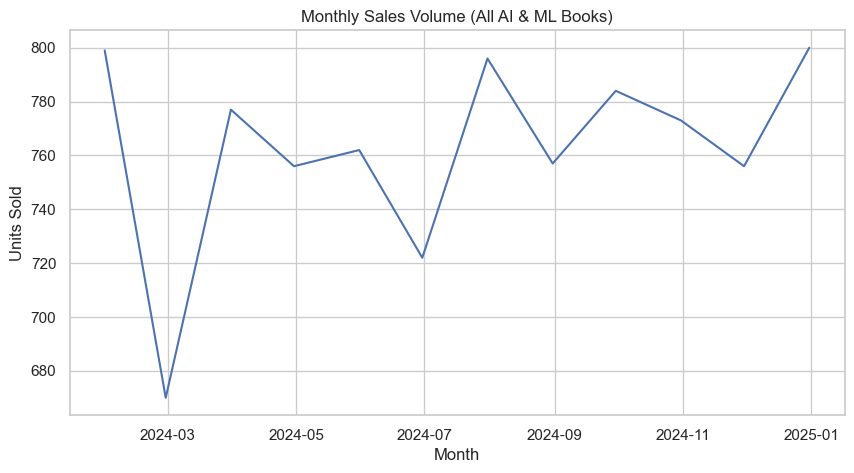

In [4]:
monthly_sales = (
    sales_df
    .groupby(pd.Grouper(key="date", freq="M"))["units_sold"]
    .sum()
    .reset_index()
)

plt.plot(monthly_sales["date"], monthly_sales["units_sold"])
plt.title("Monthly Sales Volume (All AI & ML Books)")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()


In [5]:
platform_perf = (
    sales_df
    .groupby("platform")[["units_sold", "gross_revenue"]]
    .sum()
    .sort_values("gross_revenue", ascending=False)
)

platform_perf


,units_sold,gross_revenue
platform,,
Barnes & Noble,3120,98454
Apple Books,3095,97083
Amazon,2937,90543


In [6]:
kenp_analysis = (
    sales_df[sales_df["format"] == "eBook"]
    .groupby("book_title")["kenp_pages_read"]
    .mean()
    .sort_values(ascending=False)
)

kenp_analysis


book_title
Machine Learning Foundations      447.347107
Deep Learning with Python         415.055556
AI for Real-World Applications    410.296000
Neural Networks Explained         400.190840
Applied AI in Industry            391.823529
Name: kenp_pages_read, dtype: float64

In [7]:
revenue_by_book = (
    sales_df
    .groupby("book_title")["gross_revenue"]
    .sum()
    .reset_index()
)

roi_df = revenue_by_book.merge(costs_df, on="book_title")

roi_df["annual_ad_spend"] = roi_df["monthly_ad_spend"] * 12
roi_df["net_profit"] = (
    roi_df["gross_revenue"]
    - roi_df["annual_ad_spend"]
    - roi_df["total_fixed_cost"]
)

roi_df["roi"] = roi_df["net_profit"] / roi_df["annual_ad_spend"]

roi_df[[
    "book_title",
    "gross_revenue",
    "net_profit",
    "roi"
]].sort_values("roi", ascending=False)


,book_title,gross_revenue,net_profit,roi
4,Neural Networks Explained,54990,32390,1.799444
3,Machine Learning Foundations,55539,28689,1.328194
2,Deep Learning with Python,58218,28218,1.175750
1,Applied AI in Industry,59370,27220,1.031061
0,AI for Real-World Applications,57963,21063,0.702100


In [8]:
conversion_df = pd.DataFrame({
    "platform": platforms,
    "monthly_page_visits": [120000, 45000, 38000],
    "monthly_sales": [8200, 2600, 2100]
})

conversion_df["conversion_rate"] = (
    conversion_df["monthly_sales"] /
    conversion_df["monthly_page_visits"]
)

conversion_df


,platform,monthly_page_visits,monthly_sales,conversion_rate
0,Amazon,120000,8200,0.068333
1,Barnes & Noble,45000,2600,0.057778
2,Apple Books,38000,2100,0.055263


In [9]:
format_region = (
    sales_df
    .groupby(["format", "region"])["units_sold"]
    .sum()
    .unstack()
)

format_region


region,Asia,EU,UK,US
format,,,,
Hardcover,868,780,794,750
Paperback,793,809,701,627
eBook,807,807,638,778


In [10]:
sales_df["year"] = sales_df["date"].dt.year

yoy = (
    sales_df
    .groupby(["year", "book_title"])["units_sold"]
    .sum()
    .unstack()
)

yoy


book_title,AI for Real-World Applications,Applied AI in Industry,Deep Learning with Python,Machine Learning Foundations,Neural Networks Explained
year,,,,,
2024,1872,1880,1824,1774,1802
